# **IMPORTANDO BIBLIOTECAS**

In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **IMPORTANDO DATASET DO DRIVE**

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

csv_file_path = 'southeast_reduzido_diario.csv'  # Caminho do arquivo na pasta do Drive

# **ETAPA 1.2  Carregamento e Preparação Inicial dos Dados**

In [3]:
print("- - -EXIBINDO DATASET - - -\n")
drive_df = pd.read_csv(csv_file_path)
display(drive_df.head())

print("\n- - - INFORMAÇÕES GERAIS - - -\n")
drive_df.info()
drive_df.describe()

#SOMA VALORES NULOS
print("\n- - - VALORES NULOS POR COLUNA - - -\n")
print(drive_df.isnull().sum())

# Reduzindo o tipo numérico das colunas

for col in drive_df.select_dtypes(include="float64").columns:
    drive_df[col] = drive_df[col].astype("float32")

for col in drive_df.select_dtypes(include="int64").columns:
    drive_df[col] = drive_df[col].astype("int32")

print("\nUso de memória:")
print(drive_df.memory_usage(deep=True).sum() / 1024**2, "MB")

#CALCULANDO A MÉDIA E SUBSTITUINDO OS VALORES
colunas = [
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_mean",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_max",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_min"
]

for coluna in colunas:
    drive_df[coluna] = drive_df[coluna].fillna(
        drive_df[coluna].mean()
    )

print("\n- - - IDENTIFICAÇÃO DA VARIÁVEL ALVO - - -\n")
target = "CHOVEU_CLASSIFICACAO"

print(drive_df[target].value_counts())

#Balanceamento dos dados
classe0 = drive_df[drive_df[target] == 0]
classe1 = drive_df[drive_df[target] == 1]

classe0 = classe0.sample(
    n=len(classe1),
    random_state=42
)

drive_df = pd.concat([classe0, classe1], ignore_index=True)

drive_df = drive_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nDistribuição após balanceamento:")
print(drive_df[target].value_counts())


- - -EXIBINDO DATASET - - -



,"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",Data,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)_sum","TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_mean","TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_max","TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_min","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)_mean",RADIACAO GLOBAL (Kj/m²)_sum,CHOVEU_CLASSIFICACAO
0,720.1,2020-06-01,0.0,-1.5,-1.5,-1.5,720.1,0.0,0
1,720.2,2020-07-22,0.0,-5.5,-5.5,-5.5,720.2,0.0,0
2,720.3,2020-06-01,0.0,0.8,0.8,0.8,720.3,0.0,0
3,720.4,2021-04-11,0.0,-3.6,-3.6,-3.6,720.4,0.0,0
4,720.5,2021-04-11,0.0,-3.6,-3.6,-3.6,720.5,0.0,0



- - - INFORMAÇÕES GERAIS - - -

<class 'pandas.DataFrame'>
RangeIndex: 2500969 entries, 0 to 2500968
Data columns (total 9 columns):
 #   Column                                                      Dtype  
---  ------                                                      -----  
 0   PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)       float64
 1   Data                                                        str    
 2   PRECIPITAÇÃO TOTAL, HORÁRIO (mm)_sum                        float64
 3   TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_mean           float64
 4   TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_max            float64
 5   TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_min            float64
 6   PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)_mean  float64
 7   RADIACAO GLOBAL (Kj/m²)_sum                                 float64
 8   CHOVEU_CLASSIFICACAO                                        int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 171.7 MB

- 

# **ETAPA 1.3 Análise Exploratória de Dados (EDA)**

# 1. Distribuição da variável alvo

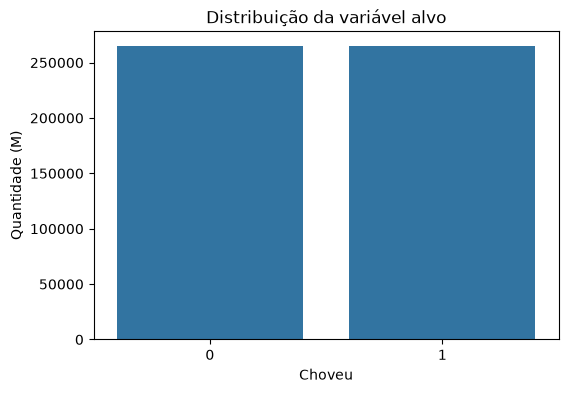

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(x="CHOVEU_CLASSIFICACAO", data=drive_df)

plt.title("Distribuição da variável alvo")
plt.xlabel("Choveu")
plt.ylabel("Quantidade (M)")

plt.show()

## O gráfico mostra a distribuição entre dias com chuva e dias sem chuva. Essa análise permite verificar se o conjunto de dados está balanceado ou se existe predominância de uma das classes.

# 2. Correlação entre as variáveis

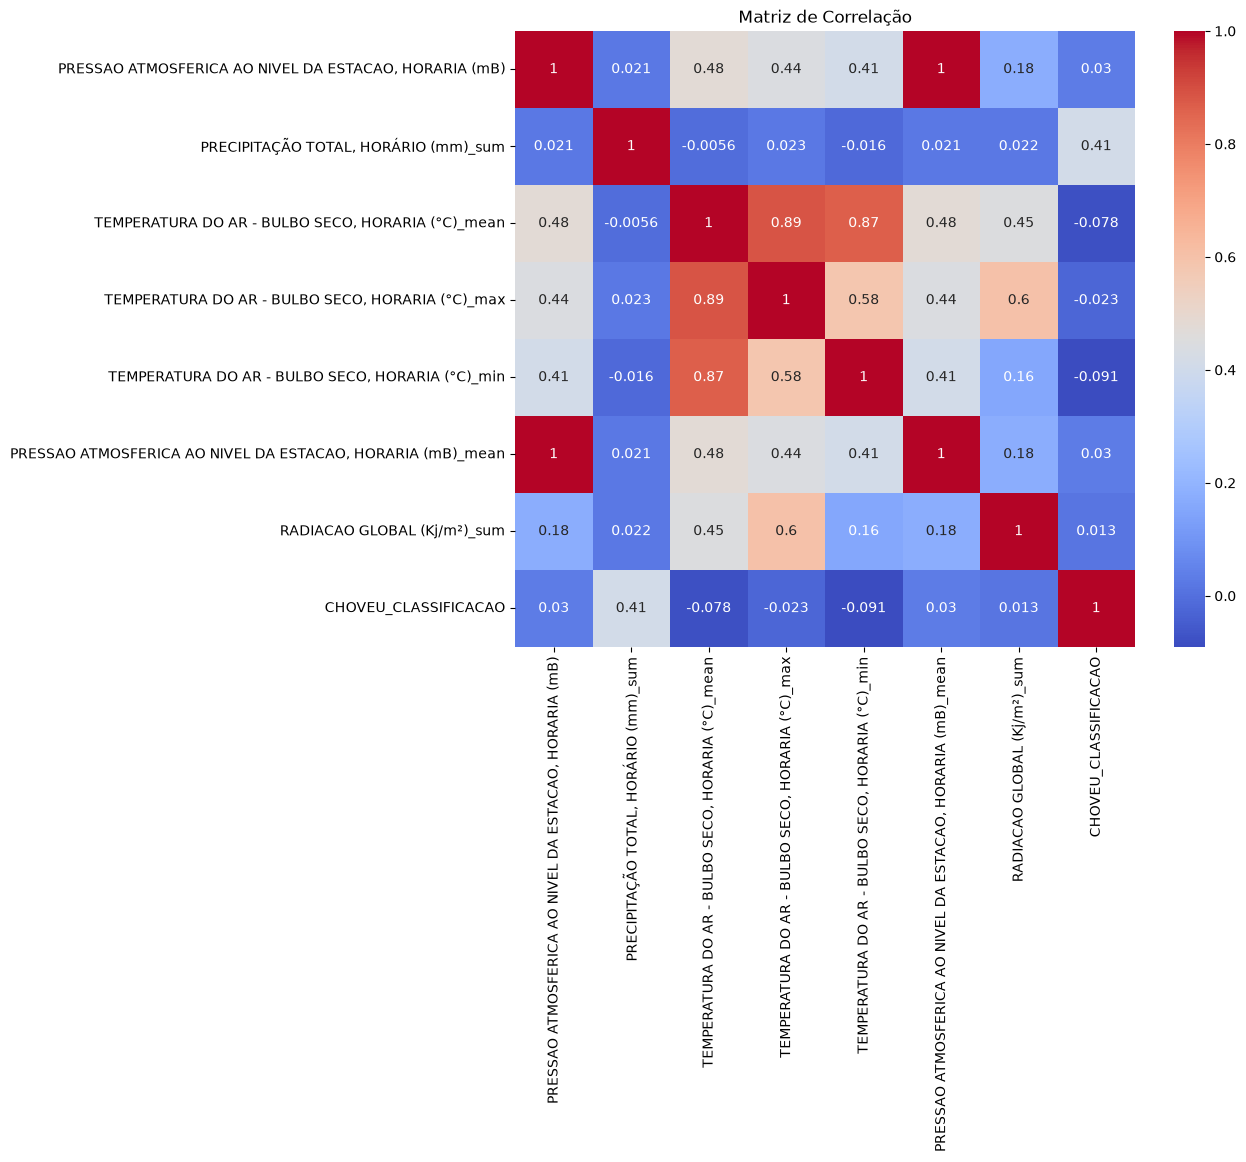

In [5]:
plt.figure(figsize=(10,8))

sns.heatmap(drive_df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Matriz de Correlação")

plt.show()

## A matriz de correlação mostra o grau de relacionamento entre as variáveis numéricas. Valores próximos de 1 indicam forte correlação positiva, enquanto valores próximos de -1 indicam correlação negativa. Essa análise ajuda a identificar quais atributos podem ser mais relevantes para a previsão da ocorrência de chuva.

# 3. Relação entre temperatura e chuva

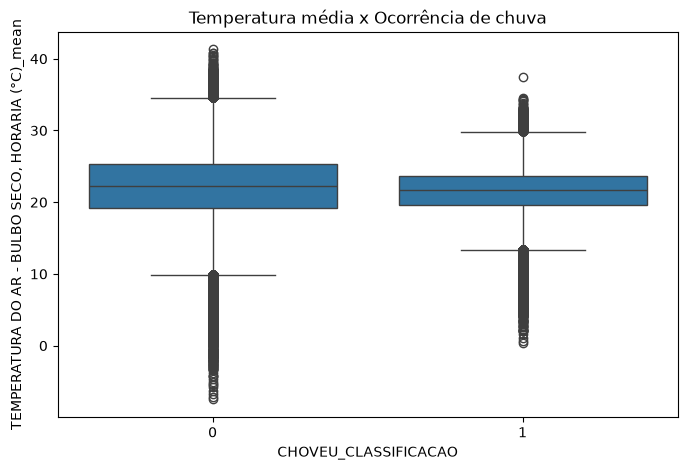

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="CHOVEU_CLASSIFICACAO",
    y="TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)_mean",
    data=drive_df
)

plt.title("Temperatura média x Ocorrência de chuva")

plt.show()

## O boxplot permite comparar a distribuição da temperatura média entre dias com e sem chuva. Diferenças significativas entre as medianas ou na dispersão podem indicar que essa variável possui influência na ocorrência de precipitação.

# 4. Relação entre radiação solar e chuva

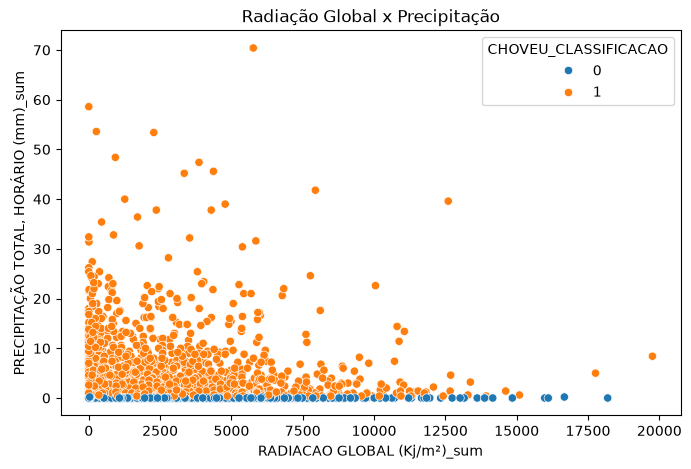

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="RADIACAO GLOBAL (Kj/m²)_sum",
    y="PRECIPITAÇÃO TOTAL, HORÁRIO (mm)_sum",
    hue="CHOVEU_CLASSIFICACAO",
    data=drive_df.sample(5000, random_state=42)
)

plt.title("Radiação Global x Precipitação")

plt.show()

Foi utilizada apenas uma amostra de 5.000 registros, pois o conjunto possui mais de 2,5 milhões de linhas, o que deixaria o gráfico muito pesado.

## O gráfico de dispersão permite observar a relação entre a radiação solar e a quantidade de precipitação. Em geral, dias com maior precipitação tendem a apresentar menor radiação solar, indicando uma possível relação inversa entre essas variáveis.

# Conclusão da Etapa 1.3 (EDA)
## A análise exploratória mostrou que o conjunto de dados possui poucas informações ausentes, facilitando o pré-processamento. As variáveis meteorológicas apresentam diferentes níveis de correlação entre si, e alguns atributos, como temperatura e radiação solar, demonstram comportamento distinto entre dias com e sem chuva. Essas características sugerem que o conjunto de dados possui informações relevantes para o treinamento de modelos de classificação capazes de prever a ocorrência de chuva.

# **Etapa 2 — Pré-processamento, Modelagem e Avaliação**

# IMPORTANDO BIBLIOTECAS

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **2.1  Pré-processamento para Modelagem**

In [9]:
#SEPARANDO VARIÁVEIS
X = drive_df.drop(columns=[target])
y = drive_df[target]

#VERIFICANDO COLUNAS CATEGÓRICAS
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=np.uint8
)

#DIVISÃO ENTRE TREINO E TESTE (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#PADRONIZAÇÃO
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **2.2 Treinamento dos Modelos**

# IMPORTANDO BIBLIOTECAS

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modelo 1 — Regressão Logística

In [11]:
modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

# Modelo 2 — Árvore de Decisão

In [12]:
modelo_dt = DecisionTreeClassifier(random_state=42)

modelo_dt.fit(X_train, y_train)

pred_dt = modelo_dt.predict(X_test)

# Modelo 3 — Random Forest

In [13]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

# 2.3  **Avaliação e Análise dos Resultados**

# IMPORTANDO BIBLIOTECAS

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

## Função para avaliar qualquer modelo

In [16]:
def avaliar_modelo(nome, y_real, y_pred):

    print("="*60)
    print(nome)
    print("="*60)

    print("Acurácia :", accuracy_score(y_real, y_pred))
    print("Precisão :", precision_score(y_real, y_pred))
    print("Recall   :", recall_score(y_real, y_pred))
    print("F1 Score :", f1_score(y_real, y_pred))

    print("\nRelatório de Classificação\n")
    print(classification_report(y_real, y_pred))

    matriz = confusion_matrix(y_real, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")

    plt.show()

# AVALIANDO OS MODELOS

Regressão Logística
Acurácia : 0.9996601497229276
Precisão : 1.0
Recall   : 0.9993202930292274
F1 Score : 0.9996600309749556

Relatório de Classificação

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     52965
           1       1.00      1.00      1.00     52964

    accuracy                           1.00    105929
   macro avg       1.00      1.00      1.00    105929
weighted avg       1.00      1.00      1.00    105929



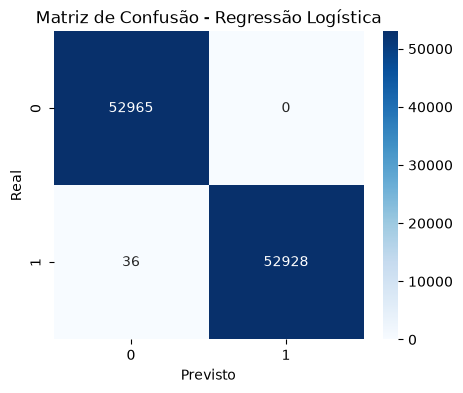

Árvore de Decisão
Acurácia : 1.0
Precisão : 1.0
Recall   : 1.0
F1 Score : 1.0

Relatório de Classificação

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     52965
           1       1.00      1.00      1.00     52964

    accuracy                           1.00    105929
   macro avg       1.00      1.00      1.00    105929
weighted avg       1.00      1.00      1.00    105929



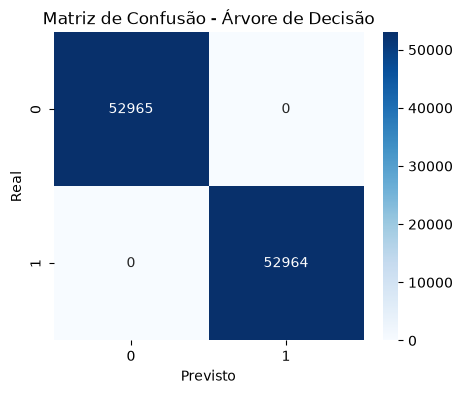

Random Forest
Acurácia : 1.0
Precisão : 1.0
Recall   : 1.0
F1 Score : 1.0

Relatório de Classificação

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     52965
           1       1.00      1.00      1.00     52964

    accuracy                           1.00    105929
   macro avg       1.00      1.00      1.00    105929
weighted avg       1.00      1.00      1.00    105929



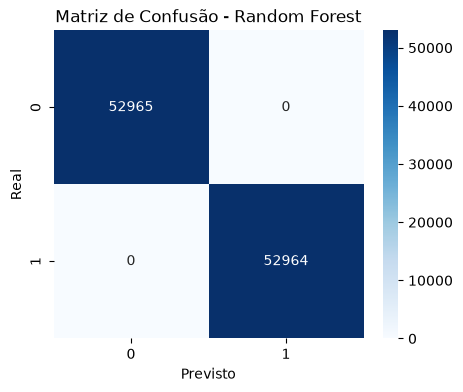

In [17]:
avaliar_modelo(
    "Regressão Logística",
    y_test,
    pred_lr
)

avaliar_modelo(
    "Árvore de Decisão",
    y_test,
    pred_dt
)

avaliar_modelo(
    "Random Forest",
    y_test,
    pred_rf
)

# **COMPARAÇÃO FINAL**

In [18]:
resultados = pd.DataFrame({

    "Modelo":[
        "Regressão Logística",
        "Árvore de Decisão",
        "Random Forest"
    ],

    "Acurácia":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf)
    ],

    "Precisão":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf)
    ],

    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf)
    ],

    "F1":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf)
    ]

})

resultados

,Modelo,Acurácia,Precisão,Recall,F1
0,Regressão Logística,0.99966,1.0,0.99932,0.99966
1,Árvore de Decisão,1.00000,1.0,1.00000,1.00000
2,Random Forest,1.00000,1.0,1.00000,1.00000


# **COMPARAÇÃO GRÁFICA**

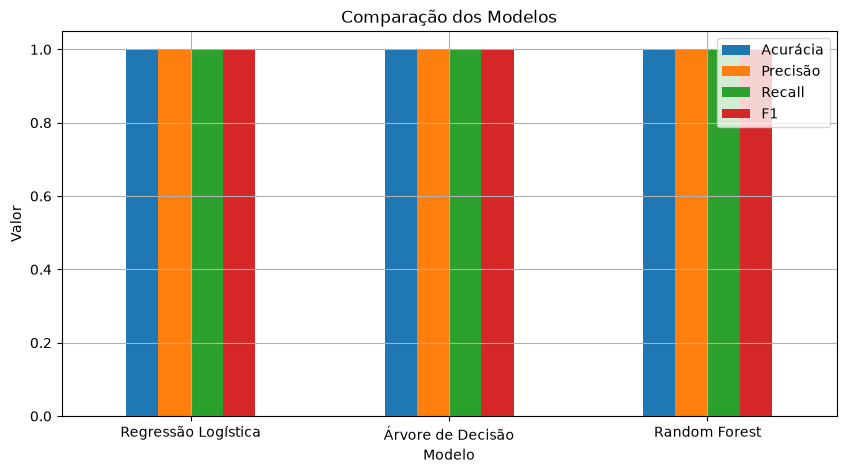

In [19]:
resultados.set_index("Modelo").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparação dos Modelos")

plt.ylabel("Valor")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

# **CONCLUSÃO**

### Foram treinados três modelos de classificação para prever a ocorrência de chuva: Regressão Logística, Árvore de Decisão e Random Forest. A comparação foi realizada utilizando as métricas de acurácia, precisão, recall e F1-Score, além da matriz de confusão. O modelo com melhor desempenho geral foi escolhido considerando sua capacidade de identificar corretamente os dias com chuva e sem chuva, minimizando erros de classificação.

### Em aplicações de previsão meteorológica, os falsos negativos (prever que não choverá quando, na realidade, haverá chuva) costumam ser mais críticos do que os falsos positivos, pois podem causar impactos no planejamento de atividades, agricultura, transporte e segurança da população. Assim, um modelo com maior recall para a classe "chuva" pode ser preferível, mesmo que apresente uma pequena redução na precisão. A escolha final deve equilibrar as métricas obtidas e o contexto da aplicação.